# Ricerca di Trading System

Questo notebook serve a **scoprire se un segnale di ingresso ha davvero un vantaggio**, e in caso affermativo a raffinarlo fino a un sistema utilizzabile.

Si legge dall'alto verso il basso. Ogni sezione usa il risultato della precedente. Non ci sono strade alternative o celle facoltative: se esegui tutto in ordine, arrivi alla fine.

---

## L'idea di fondo

Un trading system è fatto di tre pezzi: **quando entro**, **quando esco**, **quando sto fermo**.

Il problema è che se li si cerca tutti insieme non si capisce più quale dei tre stia funzionando. Un ingresso mediocre con un'uscita fortunata sembra buono; un ingresso ottimo con un'uscita sbagliata sembra pessimo. È il motivo per cui la maggior parte delle ricerche fatte a tentativi non porta da nessuna parte.

Qui li separiamo, e li affrontiamo in quest'ordine:


---

## Il trucco che rende tutto questo possibile

Nella Sessione 1 ...

In [1]:
!pip install -q TA-Lib backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 13.5 MB/s eta 0:00:00


### Sezione 0 · Preparazione


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Creator_V4')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Creator_V4.git

%cd Trading-System-Creator_V4

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Creator_V4'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 76 (delta 33), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 1.25 MiB | 2.57 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/Trading-System-Creator_V4


In [4]:
import datetime as dt
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta

import entry_long, entry_short
from entry_short import aggiungi_trigger_short
import engine as eng
from engine.vwap_ops import vwap_anchored_daily
import engine.event_study
import engine.splitting
from engine.exit_search_bt import run_exit_search_bt

/usr/local/lib/python3.13/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Sezione 1 · I dati

Scarica le candele da MetaTrader 5.

**Parametri che puoi cambiare:** lo strumento, il timeframe, il periodo storico e la leva.

Sulla **leva**: non moltiplica solo i guadagni, introduce la liquidazione. Il motore lo sa e applica automaticamente uno stop di sicurezza sotto la soglia teorica (`1/leva`), così un backtest a leva alta non ti mostra profitti che nella realtà non avresti mai visto perché il conto sarebbe stato azzerato prima. Con `LEVERAGE = 1` non succede niente di tutto questo.

In [5]:
symbol    = "EURUSD"
timeframe = 'M15'
FREQ      = "15min"      # come pandas scrive il timeframe: "15min", "h", "D"

df = pd.read_csv('EURUSD_M15.csv', index_col='Date')
df.index = pd.to_datetime(df.index, utc=True)

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

EURUSD M15 — 91,596 barre  ·  da 2023-01-02 00:00:00+00:00  a  2026-09-07 06:45:00+00:00


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-07 06:15:00+00:00,1.16095,1.16121,1.16092,1.16119,232
2026-09-07 06:30:00+00:00,1.16119,1.16121,1.16089,1.16095,341
2026-09-07 06:45:00+00:00,1.16095,1.16117,1.16090,1.16117,270


## Sezione 2 · Gli indicatori

Le regole di trading (in `conditions/`) non calcolano niente da sole: leggono colonne già pronte in questa tabella. Qui le costruiamo.

**Cosa aggiungiamo e a cosa serve:**

| Colonna | Cos'è | Chi la usa |
|---|---|---|
| `rsi` | oscillatore 0-100: sotto 30 il prezzo è "sceso troppo", sopra 70 "salito troppo" | l'entry mean reversion |
| `ema20`, `ema50` | medie mobili veloce e lenta | l'entry di controllo |
| `zlema50` | media mobile **a ritardo ridotto** | l'entry di trend |
| `atr`, `realized_vol` | quanto si muove il prezzo di solito | dimensionamento futuro |
| `vwap` | prezzo medio della giornata pesato per volume | i filtri di contesto |

Sulla **zero-lag EMA**: una media mobile normale è sempre in ritardo, perché fa la media di prezzi passati. La ZLEMA compensa il ritardo proiettando in avanti il prezzo. In cambio, esagera i movimenti e genera più falsi attraversamenti. Ne genererà parecchi su M15 — il che va bene per la ricerca (più campioni), ma è la condizione in cui i costi di transazione pesano di più.

In [6]:
df["rsi"] = ta.RSI(df["Close"], timeperiod=14)
df['macd'], df['macd_signal'], df['macd_hist'] = ta.MACD(df["Close"], fastperiod=12, slowperiod=26, signalperiod=9)
df["ema20"] = df["Close"].ewm(span=20, min_periods=20).mean()   # ← min_periods
df["ema50"] = df["Close"].ewm(span=50, min_periods=50).mean()   # ← min_periods
def zlema(series, period):
    """Media mobile a ritardo ridotto: proietta il prezzo per compensare il lag."""
    lag = int((period - 1) / 2)
    return (2 * series - series.shift(lag)).ewm(span=period, adjust=False).mean()

df["zlema50"] = zlema(df["Close"], 50)
df["atr"] = ta.ATR(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ATR vero
df["realized_vol"] = df["Close"].pct_change().rolling(96).std()
df["adx"] = ta.ADX(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ADX vero
df["vwap"] = vwap_anchored_daily(df)
df.dropna(inplace=True)
print(f"{len(df):,} barre pronte, {df.shape[1]} colonne")
print(f"adx  — min {df['adx'].min():.1f}  mediana {df['adx'].median():.1f}  max {df['adx'].max():.1f}")
print(f"atr  — mediana {df['atr'].median():.6f}  ({df['atr'].median()/df['Close'].median()*100:.3f}% del prezzo)")
df.tail(3)

91,500 barre pronte, 16 colonne
adx  — min 6.0  mediana 22.6  max 74.5
atr  — mediana 0.000572  (0.052% del prezzo)


,Open,High,Low,Close,Volume,rsi,macd,macd_signal,macd_hist,ema20,ema50,zlema50,atr,realized_vol,adx,vwap
Date,,,,,,,,,,,,,,,,
2026-09-07 06:15:00+00:00,1.16095,1.16121,1.16092,1.16119,232,47.213804,-0.000099,-0.000045,-0.000054,1.161270,1.161424,1.161232,0.000294,0.000326,14.596341,1.161405
2026-09-07 06:30:00+00:00,1.16119,1.16121,1.16089,1.16095,341,42.349954,-0.000112,-0.000058,-0.000054,1.161240,1.161405,1.161225,0.000296,0.000325,14.303121,1.161385
2026-09-07 06:45:00+00:00,1.16095,1.16117,1.16090,1.16117,270,47.671587,-0.000103,-0.000067,-0.000036,1.161233,1.161396,1.161245,0.000294,0.000326,14.030846,1.161373


## Sezione 3 · Dividere i dati in due

Questa è la regola più importante del notebook, e l'unica che non si può violare.

Dividiamo la storia in due parti:

- **In-Sample (80%)** — la parte su cui si cerca, si prova, si sbaglia, si riprova quante volte si vuole
- **Out-of-Sample (20%)** — la parte che **non si guarda fino alla fine**

Perché conta: se provi mille combinazioni su tutti i dati, qualcuna sembrerà eccellente **per puro caso**. È matematicamente garantito che accada, anche su dati completamente casuali. L'unico modo per accorgersene è tenere da parte dei dati che nessuna delle mille combinazioni ha mai visto, e controllare lì alla fine.

Se guardi l'Out-of-Sample, cambi qualcosa e riguardi, l'Out-of-Sample non esiste più: è diventato parte della ricerca, e il notebook smette di dirti la verità. **Si apre una volta sola, alla Sezione 7.**

In [7]:
IS_RATIO = 0.8
df_is, df_oos = eng.splitting.split_is_oos(df, is_ratio=IS_RATIO)
eng.splitting.describe_split(df_is, df_oos)

,n_barre,quota,dal,al
In-Sample,73200,0.8,2023-01-03 00:00:00+00:00,2025-12-10 13:45:00+00:00
Out-of-Sample,18300,0.2,2025-12-10 14:00:00+00:00,2026-09-07 06:45:00+00:00
Totale,91500,1.0,2023-01-03 00:00:00+00:00,2026-09-07 06:45:00+00:00


## Sezione 4 · Features Engineering

In [8]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).


In [7]:
df_is = entry_long.aggiungi_trigger_long(df_is)
df_is

,Open,High,Low,Close,Volume,rsi,macd,macd_signal,macd_hist,ema20,...,E14_HARAMI_CROSS,E14_HARAMI_CROSS_CONFIRMED,E15_PIERCING,E16_MORNING_STAR,E17_THREE_INSIDE,E18_THREE_OUTSIDE,E19_THREE_WHITE_SOLDIERS,E20_MARUBOZU,E21_BELT_HOLD,E21_BELT_HOLD_CONFIRMED
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03 00:00:00+00:00,1.06650,1.06651,1.06612,1.06651,25,51.904458,-0.000070,-0.000226,0.000155,1.066279,...,False,False,False,False,False,False,False,False,False,False
2023-01-03 00:15:00+00:00,1.06651,1.06652,1.06650,1.06652,28,52.041260,-0.000047,-0.000190,0.000143,1.066302,...,False,False,False,False,False,False,False,False,False,False
2023-01-03 00:30:00+00:00,1.06652,1.06652,1.06638,1.06638,22,49.901266,-0.000039,-0.000160,0.000121,1.066309,...,False,False,False,False,False,False,False,False,False,False
2023-01-03 00:45:00+00:00,1.06638,1.06659,1.06629,1.06646,33,51.137740,-0.000026,-0.000133,0.000107,1.066324,...,False,False,False,False,False,False,False,False,False,False
2023-01-03 01:00:00+00:00,1.06677,1.06836,1.06633,1.06638,686,49.813728,-0.000022,-0.000111,0.000089,1.066329,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 12:45:00+00:00,1.16309,1.16358,1.16276,1.16347,751,47.073309,0.000122,0.000300,-0.000179,1.163782,...,False,False,False,False,False,False,False,False,False,False
2025-12-10 13:00:00+00:00,1.16346,1.16360,1.16313,1.16326,642,44.545177,0.000068,0.000254,-0.000186,1.163733,...,False,False,False,False,False,False,False,False,False,False
2025-12-10 13:15:00+00:00,1.16326,1.16383,1.16321,1.16352,522,48.250850,0.000045,0.000212,-0.000167,1.163712,...,False,False,False,False,False,False,False,False,False,False


## SESSIONE 1 · L'andamento del prezzo dopo il trigger

Per ogni condizione di ingresso: prendiamo **tutte** le barre in cui è vera e guardiamo dove va il prezzo nelle barre successive, fino all'orizzonte `H`.

Si entra all'apertura della barra dopo il segnale — mai sullo stesso Close che l'ha generato, che sarebbe impossibile nella realtà. La curva è sempre "a favore del trade": per una condizione short, sale quando il prezzo scende.

**Nessuna occorrenza viene scartata.** Il metodo precedente buttava via i trigger che scattavano mentre eravamo già dentro un trade: a 96 barre significava perdere la grande maggioranza degli eventi. Qui c'è tutto.

`H` non è una griglia da scegliere: si calcola una volta fino a 96 barre e tutti gli orizzonti intermedi si leggono sulla curva.

## 1.1 · Le curve a confronto

Ogni linea è una condizione. L'asse orizzontale sono le barre dal trigger, quello verticale la variazione media del prezzo in percentuale.

**La linea nera tratteggiata è il mercato**: il movimento medio dopo una barra qualsiasi, senza nessuna condizione. È il metro di paragone. Una curva che ci sta sopra sta aggiungendo qualcosa; una che ci si appiccica non sta dicendo niente.

Guarda la **forma**: sale e prosegue (il movimento continua), sale e si appiattisce (il vantaggio ha una scadenza, ed è lì l'orizzonte del trade), sale e ridiscende (quello che avevi guadagnato lo restituisci).

In [13]:
H = 8
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.10)
10 entry scartate sotto min_trades=200
  barra   1/8
  barra   2/8
  barra   3/8
  barra   4/8
  barra   5/8
  barra   6/8
  barra   7/8
  barra   8/8

42 entry · orizzonte 8 barre · 96,675 trigger misurati


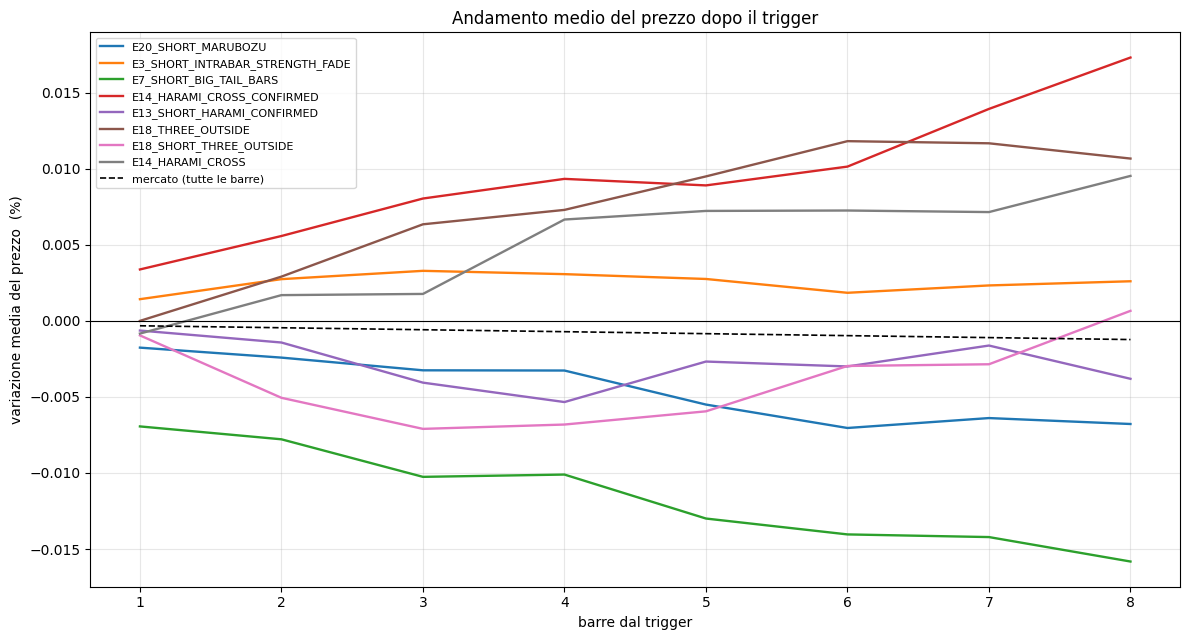

In [14]:
ev = eng.event_study.run_event_study(df_is, horizon=H, min_trades=MIN_TRADES)
ev.plot()
#ev.plot_singola("E7_BIG_TAIL_BARS", pips=True)

## 1.2 · La sintesi

Una riga per condizione, ordinata per ampiezza del movimento.

| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `barra_picco` | dopo quante barre il movimento è più ampio — **è l'orizzonte naturale di quel segnale** |
| `picco_pct` | di quanto si è mosso il prezzo, in percentuale, al picco |
| `a_fine_pct` | dov'è il prezzo all'orizzonte massimo: più basso del picco = il movimento è rientrato |
| `vs_mercato_pct` | quanto il trigger si discosta dal movimento che il mercato fa comunque |

`vs_mercato_pct` vicino a zero significa che quello che vedi non è il segnale: è il respiro dell'asset.

In [15]:
ev.sintesi.round(4).head(10)

,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda
0,E20_SHORT_MARUBOZU,-1,1963,6,-0.7730,-0.0070,0.0023,-3.0054,-0.0068,-0.0061,6,True
1,E3_SHORT_INTRABAR_STRENGTH_FADE,-1,5130,3,0.3601,0.0033,0.0012,2.6495,0.0026,0.0039,3,False
2,E7_SHORT_BIG_TAIL_BARS,-1,543,8,-1.7331,-0.0158,0.0061,-2.6030,-0.0158,-0.0146,8,True
3,E14_HARAMI_CROSS_CONFIRMED,1,463,8,1.9021,0.0173,0.0068,2.5558,0.0173,0.0161,8,True
4,E13_SHORT_HARAMI_CONFIRMED,-1,1808,4,-0.5862,-0.0053,0.0021,-2.5365,-0.0038,-0.0046,4,False
5,E18_THREE_OUTSIDE,1,636,6,1.2916,0.0118,0.0050,2.3723,0.0107,0.0108,6,True
6,E18_SHORT_THREE_OUTSIDE,-1,656,3,-0.7753,-0.0071,0.0030,-2.3640,0.0007,-0.0065,3,False
7,E14_HARAMI_CROSS,1,923,8,1.0455,0.0095,0.0046,2.0489,0.0095,0.0083,8,True
8,E13_HARAMI_CONFIRMED,1,1843,8,0.6923,0.0063,0.0031,2.0364,0.0063,0.0051,8,True
9,E5_SHORT_QUICK_PULLBACK,-1,1549,8,-0.7648,-0.0070,0.0036,-1.9173,-0.0070,-0.0057,8,True


In [16]:
ev.diagnosi()

orizzonte impostato          : 8 barre
picchi (netti) nell'ultimo quarto: 60% (25/42, oltre la barra 6)
|picco| / incertezza, mediana: 1.39
|picco| / incertezza, massimo: 3.01

I picchi si ammassano in fondo alla finestra: e' il
comportamento di una deriva casuale, non di un segnale.
Prova a rileggere con horizon=4
e guarda se la forma delle curve cambia.


# SESSIONE 2 · Le condizioni di uscita

Fin qui abbiamo **misurato** un segnale: nessun capitale, nessuna posizione, nessun costo. Da adesso costruiamo un **sistema**: si sceglie un ingresso e si cerca il modo di uscirne.

## 2.1 · Come vengono calcolati stop e target

Una soglia fissa in percentuale non è trasferibile da un asset all'altro: uno stop dello 0.15% è larghissimo su EURUSD e strettissimo su BTCUSD. Qui non c'è nessuna soglia scritta a mano.

Per ogni barra si misura quanto sarebbe andato in rosso, e quanto in verde, un trade aperto lì e tenuto `n` barre. Lo stop del trade che apri adesso è il **percentile richiesto di quelle escursioni sulle ultime 500 occorrenze concluse**. Su uno strumento volatile lo stop si allarga da solo; quando il mercato si calma si stringe. Lo stesso numero (`90`) significa la stessa cosa su qualunque asset.

Il valore **si fissa all'apertura del trade e non cambia più**: a variare barra per barra è il dato di riferimento, non lo stop di una posizione già aperta.

> **Perché "occorrenze concluse".** L'escursione di un trade partito alla barra `i` si conosce solo alla barra `i+n`. Se il percentile si calcolasse sulle ultime 500 occorrenze *partite*, le più recenti non sarebbero ancora finite: staremmo usando prezzi futuri per decidere lo stop di un trade che apriamo adesso, e lo stop risulterebbe magicamente tarato sulla volatilità in arrivo. La finestra è quindi piena ma spostata indietro di `n` barre.

Una conseguenza utile: **orizzonte e stop smettono di essere due parametri separati**. A 16 barre lo stop è quello dell'escursione tipica a 16 barre; a 64 si allarga da solo.

## 2.2 · La classifica

Una riga per combinazione, ordinata per Sharpe. La colonna `combinazione` si legge *"esci con questa regola, oppure dopo questo numero di barre, a seconda di cosa arriva prima"*.

| colonna | cosa dice |
|---|---|
| `trades` | quanti trade ha prodotto |
| `pnl_pct` | rendimento totale sul periodo |
| `sharpe` | rendimento rapportato alla sua variabilità |
| `max_dd_pct` | la perdita peggiore dal picco precedente |
| `win_rate_pct` | percentuale di trade in guadagno |
| `profit_factor` | quanto incassano i vincenti per ogni euro perso dai perdenti: sotto 1 il sistema perde |
| `avg_trade_pips` | guadagno medio per trade, in pips — **il numero da confrontare col costo** |
| `durata_media` | quanto durano davvero i trade |
| `esposizione_pct` | quanto tempo si sta effettivamente a mercato |

Il confronto che conta più di tutti: **ogni riga con una regola va confrontata con la riga `SOLO_TEMPO` dello stesso orizzonte.** Se non la batte, quella regola non sta aggiungendo niente e stai solo pagando più commissioni.

Attenzione al win rate da solo: il 70% di trade vincenti con perdite doppie dei guadagni è un sistema perdente. Per quello ci sono `profit_factor` e `avg_trade_pips`.

In [32]:
es = run_exit_search_bt(df_is, entry_cols_long=["E14_HARAMI_CROSS_CONFIRMED", None],
                        entry_cols_short=["E1_SHORT_RSI_CROSS_OVERBOUGHT", None],
                        n_barre=8, perc_sl=90.0, perc_tp=0.0,
                        commission=0.0,)
es.top(10)
#es.trades("L=E7_BIG_TAIL_BARS · S=E9_SHORT_CLOSING_PATTERN_ONLY_II")

1 combinazione/i (None, None) scartata/e: nessun ingresso.
segnali ignorati per soglia non calcolabile — E14_HARAMI_CROSS_CONFIRMED: 5, E1_SHORT_RSI_CROSS_OVERBOUGHT: 10


Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

3 combinazioni · n_barre=8 · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,durata_media,durata_max
0,L=E14_HARAMI_CROSS_CONFIRMED · S=—,439,8.107,1.368,-1.388,52.847,1.532,1.938,7.729,8
1,L=E14_HARAMI_CROSS_CONFIRMED · S=E1_SHORT_RSI_...,1150,10.757,1.073,-3.659,52.348,1.202,0.981,7.494,8
2,L=— · S=E1_SHORT_RSI_CROSS_OVERBOUGHT,766,3.280,0.447,-3.133,51.697,1.084,0.473,7.341,8


In [27]:
ev.sintesi[ev.sintesi['candidato'].str.contains('SHORT')][['candidato','picco_pips','picco_pct']]

,candidato,picco_pips,picco_pct
0,E20_SHORT_MARUBOZU,-0.773002,-0.007046
1,E3_SHORT_INTRABAR_STRENGTH_FADE,0.360125,0.003282
2,E7_SHORT_BIG_TAIL_BARS,-1.733092,-0.015822
4,E13_SHORT_HARAMI_CONFIRMED,-0.586246,-0.005341
6,E18_SHORT_THREE_OUTSIDE,-0.775269,-0.007104
9,E5_SHORT_QUICK_PULLBACK,-0.764837,-0.006971
11,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.831177,0.007562
12,E12_SHORT_ENGULFING,-0.306175,-0.002791
13,E12_SHORT_ENGULFING_CONFIRMED,-0.369972,-0.003374
14,E8_SHORT_CLOSING_PATTERN_ONLY,-0.469341,-0.004284
